<>:116: SyntaxWarning: invalid escape sequence '\l'
<>:137: SyntaxWarning: invalid escape sequence '\O'
<>:210: SyntaxWarning: invalid escape sequence '\g'
<>:245: SyntaxWarning: invalid escape sequence '\g'
<>:246: SyntaxWarning: invalid escape sequence '\O'
<>:116: SyntaxWarning: invalid escape sequence '\l'
<>:137: SyntaxWarning: invalid escape sequence '\O'
<>:210: SyntaxWarning: invalid escape sequence '\g'
<>:245: SyntaxWarning: invalid escape sequence '\g'
<>:246: SyntaxWarning: invalid escape sequence '\O'
C:\Users\webbd\AppData\Local\Temp\ipykernel_34864\1470881706.py:116: SyntaxWarning: invalid escape sequence '\l'
  label="S({:.0f}/2)$\leftrightarrow$D({:.0f}/2)".format(
C:\Users\webbd\AppData\Local\Temp\ipykernel_34864\1470881706.py:137: SyntaxWarning: invalid escape sequence '\O'
  plt.ylabel("Relative Rabi \n frequency $\Omega$")
C:\Users\webbd\AppData\Local\Temp\ipykernel_34864\1470881706.py:210: SyntaxWarning: invalid escape sequence '\g'
  label="Chosen $\gamma$",
C:\U

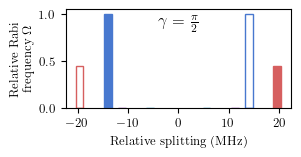

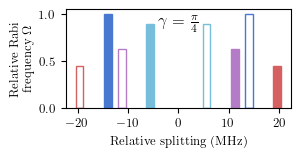

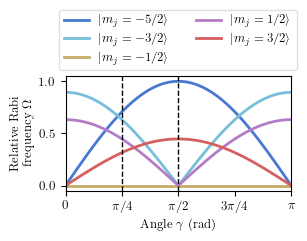

In [39]:
from atomic_physics.ions.ca40 import Ca40
import numpy as np
import matplotlib.pyplot as plt
import graph_style as gs

gs.set_graph_style(1)

B_experiment = 5.0e-4  
ion = Ca40(B=B_experiment)
transition = ion.transitions["729"]


def get_rabi_frequency(lower_, upper_, gamma_):
    """Calculates Rabi frequency for transition lower_ <--> upper_
    for angle gamma_ between B-field and polarisation.
    I assume k is perpendicular to both B and polarisation.
    gamma: angle between B-field and polarisation vector
    phi_: angle between k-vector and B-field
    Full angular dependence can be found in link:
    https://quantumoptics.at/images/publications/dissertation/gulde_diss.pdf
    """

    I0 = ion.I0("729")
    I = 1.0
    phi_ = np.pi / 2

    q = ion.M[upper_] - ion.M[lower_]

    if np.abs(q) == 1:
        g = (
            1
            / np.sqrt(6)
            * np.abs(
                (np.cos(gamma_) * np.cos(2 * phi_))
                + 1j * (np.sin(gamma_) * np.cos(phi_))
            )
        )
    elif np.abs(q) == 2:
        g = (
            1
            / np.sqrt(6)
            * np.abs(
                1 / 2 * np.cos(gamma_) * np.sin(2 * phi_)
                + 1j * np.sin(gamma_) * np.sin(phi_)
            )
        )
    elif np.abs(q) == 0:
        g = 1 / 2 * np.abs(np.cos(gamma_) * np.sin(2 * phi_))
    else:
        raise ValueError("q must be 0, 1 or 2, but is {}".format(q))

    # Extracting Rabi frequency using definition in the atomic physics docs
    # https://github.com/OxfordIonTrapGroup/atomic_physics/pull/10 (could contain mistakes)
    Rabi_peak_sqrd = ion.GammaJ[upper_] * ion.Gamma[lower_, upper_] * I / I0 / 4

    Rabi = np.sqrt(Rabi_peak_sqrd) * g
    return Rabi


def get_zeeman_spliting(lower_, upper_, B_):
    """Calculates energy splitting of  lower_ and upper_ for non-zero
    magnetic field strength, relative to splitting at B=0
    """
    dfreq = (Ca40(B=B_).E[upper_] - Ca40(B=B_).E[lower_]) / (2 * np.pi)  # [Hz]
    return dfreq


def plot_QP_transition_spectrum(gamma, label=""):
    """ " Plots spectrum of QP transitions (S12 <--> D52) with heights proportional
    to the Rabi frequency of the transition for a given angle between B and polarisation
    """
    # Find largest Rabi frequency to normalise against
    max_rabi = 0
    for M_l_sign in [1, -1]:
        M_l = M_l_sign * 1 / 2
        lower = ion.index(transition.lower, M_l)
        for M_u in M_l_sign * np.array([5 / 2, 3 / 2, 1 / 2, -1 / 2, -3 / 2]):
            upper = ion.index(transition.upper, M_u)
            if get_rabi_frequency(lower, upper, gamma) > max_rabi:
                max_rabi = get_rabi_frequency(lower, upper, gamma)

    fig_width =gs.get_fig_width()*0.5
    fig_height = fig_width * 0.8
    fig, ax = plt.subplots(1, 1, figsize=(fig_width, fig_height))
    cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
    for M_l_sign in [1, -1]:
        M_l = M_l_sign * 1 / 2
        lower = ion.index(transition.lower, M_l)

        if M_l_sign == -1:
            ls = "solid"
            fl = True
        else:
            ls = "dashed"
            fl = False

        for M_u in M_l_sign * np.array([5 / 2, 3 / 2, 1 / 2, -1 / 2, -3 / 2]):
            upper = ion.index(transition.upper, M_u)

            relative_splitting = (
                get_zeeman_spliting(lower, upper, B_=B_experiment) * 1e-6
            )  # MHz

            normalized_rabi = get_rabi_frequency(lower, upper, gamma) / max_rabi

            # set color based on the index in the array
            if M_u != M_l:
                c = cycle[int(M_u * M_l_sign - 5 / 2)]
                ax.bar(
                    relative_splitting * np.ones(2),
                    [0, normalized_rabi],
                    width=1.5,
                    fill=fl,
                    color=c,
                    edgecolor=c,
                    label="S({:.0f}/2)$\leftrightarrow$D({:.0f}/2)".format(
                        2 * M_l, 2 * M_u
                    ),
                    zorder=2,
                )
    # Shrink current axis's height by 20% on the bottom
    box = ax.get_position()
    ax.set_position([box.x0, box.y0 - box.height * 0.05, box.width, box.height * 0.55])
    # put text top center of the chosen gamma angle
    ax.text(
        0,
        0.82,
        r"$\gamma = \frac{\pi}{%d}$" % (np.pi / gamma),
        transform=ax.transData,
        size=12,
        horizontalalignment="center",
        verticalalignment="bottom",
    )

    ax.set_ylim([0, 1.05])
    plt.xlabel("Relative splitting (MHz)")
    plt.ylabel("Relative Rabi \n frequency $\Omega$")
    ax.grid(None)
    f_name = "..\\..\\pdf_figure\\ch2\\qp_transition_spectrum_{:.2f}.pdf".format(gamma / np.pi)
    plt.savefig(f_name, bbox_inches="tight")
    return


plot_QP_transition_spectrum(gamma=np.pi / 2, label="b")
plot_QP_transition_spectrum(gamma=np.pi / 4, label="c")

fig_width = 0.5 * gs.get_fig_width()
fig_height = fig_width * 0.75
# add buffer to the top of the figure for the legend
fig, (axu, ax) = plt.subplots(
    2, 1, gridspec_kw={"height_ratios": [1, 3]}, figsize=(fig_width, fig_height),
)

lower = ion.index(transition.lower, -1 / 2)
upper = ion.index(transition.upper, -5 / 2)
max_rabi = get_rabi_frequency(lower, upper, np.pi / 2)

cycle = plt.rcParams["axes.prop_cycle"].by_key()["color"]
for M_l_sign in [-1]:
    M_l = M_l_sign * 1 / 2
    lower = ion.index(transition.lower, M_l)

    if M_l_sign == -1:
        ls = "solid"
    else:
        ls = "dashed"

    for M_u in M_l_sign * np.array([5 / 2, 3 / 2, 1 / 2, -1 / 2, -3 / 2]):
        upper = ion.index(transition.upper, M_u)

        relative_splitting = (
            get_zeeman_spliting(lower, upper, B_=B_experiment) * 1e-6
        )  # MHz

        gamma_scan = np.linspace(0, np.pi, 100)
        rabi_arr = []

        for gamma in gamma_scan:
            rabi = get_rabi_frequency(lower, upper, gamma) / max_rabi
            rabi_arr.append(rabi)
        c = cycle[int(M_u * M_l_sign - 5 / 2)]
        label=fr"$|m_j={{{2*M_u:.0f}}}/2\rangle$"
        axu.plot(
            0,
            0,
            color=c,
            ls=ls,
            lw=2,
            label=label
        )
        ax.plot(
            gamma_scan,
            rabi_arr,
            color=c,
            ls=ls,
            lw=2,
            label=label
        )
# plot pi/2 dashed line
ax.axvline(
    np.pi / 2,
    color="black",
    ls="dashed",
    label="Chosen polarisation",
)
ax.axvline(
    np.pi / 4,
    color="black",
    ls="dashed",
    label="Chosen $\gamma$",
)


# Shrink current axis's height by 20% on the bottom
box = ax.get_position()
# ax.set_position([box.x0, box.y0 - box.height * 0.05, box.width, box.height * 0.55])

# Put a legend above grid
# move legend up
axu.legend(
    loc="upper center",
    fancybox=True,
    ncol=2,
    fontsize=9,
    bbox_to_anchor=(0.5, 1.5)

)
# Hide everything from upper plot apart from the legend
axu.set_xticks([])
axu.set_yticks([])
axu.spines["top"].set_visible(False)
axu.spines["right"].set_visible(False)
axu.spines["left"].set_visible(False)
axu.spines["bottom"].set_visible(False)
axu.tick_params(axis="both", which="both", length=0, labelsize=0, labelcolor="none")
ax.grid(None)


# change x ticks to radians in pi
plt.xticks(
    np.linspace(0, np.pi, 5),
    [r"$0$", r"$\pi/4$", r"$\pi/2$", r"$3\pi/4$", r"$\pi$"],
)
plt.yticks([0,0.5,1])
plt.xlabel("Angle $\gamma$ (rad)")
plt.ylabel("Relative Rabi \n frequency $\Omega$")
plt.ylim([-0.05, 1.05])
plt.xlim([0, np.pi])
axu.grid(None)

f_name = "..\\..\\pdf_figure\\ch2\\qp_gamma.pdf"
plt.savefig(f_name, bbox_inches="tight")